<a href="https://colab.research.google.com/github/AkshNaidu/single_cell_analysis/blob/main/single_cell_one.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Install Seurat (only run once)
install.packages('Seurat')
install.packages('dplyr')
install.packages('ggplot2')
install.packages('patchwork')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [3]:
# Load libraries
library(Seurat)
library(dplyr)
library(ggplot2)
library(patchwork)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [4]:
# Create directories
dir.create("data", showWarnings = FALSE)

In [5]:
# Download the dataset (takes ~1 minute)
download.file(
  url = "https://cf.10xgenomics.com/samples/cell/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz",
  destfile = "data/pbmc3k_data.tar.gz"
)

In [6]:
# Load the raw data (10X format)
untar("data/pbmc3k_data.tar.gz", exdir = "data/")

In [7]:
# Check if it worked
list.files("data/filtered_gene_bc_matrices/hg19/")

[1] "barcodes.tsv" "genes.tsv"    "matrix.mtx"

In [8]:
# Load the data (note the updated path!)
pbmc.data <- Read10X(data.dir = "data/filtered_gene_bc_matrices/hg19/")

In [9]:
# Check what you loaded
dim(pbmc.data)

[1] 32738  2700

In [10]:
# Create Seurat object
pbmc <- CreateSeuratObject(counts = pbmc.data,
                           project = "pbmc3k",
                           min.cells = 3,
                           min.features = 200)

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”


In [11]:
pbmc

An object of class Seurat 
13714 features across 2700 samples within 1 assay 
Active assay: RNA (13714 features, 0 variable features)
 1 layer present: counts

In [12]:
# Calculate % of mitochondrial genes (dying cells have high %)
pbmc[["percent.mt"]] <- PercentageFeatureSet(pbmc, pattern = "^MT-")

# Calculate % of ribosomal genes
pbmc[["percent.ribo"]] <- PercentageFeatureSet(pbmc, pattern = "^RP[SL]")



In [13]:
head(pbmc@meta.data)


,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,percent.ribo
,<fct>,<dbl>,<int>,<dbl>,<dbl>
AAACATACAACCAC-1,pbmc3k,2419,779,3.0177759,43.69574
AAACATTGAGCTAC-1,pbmc3k,4903,1352,3.7935958,42.40261
AAACATTGATCAGC-1,pbmc3k,3147,1129,0.8897363,31.68097
AAACCGTGCTTCCG-1,pbmc3k,2639,960,1.7430845,24.25161
AAACCGTGTATGCG-1,pbmc3k,980,521,1.2244898,14.89796
AAACGCACTGGTAC-1,pbmc3k,2163,781,1.6643551,36.19972


Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


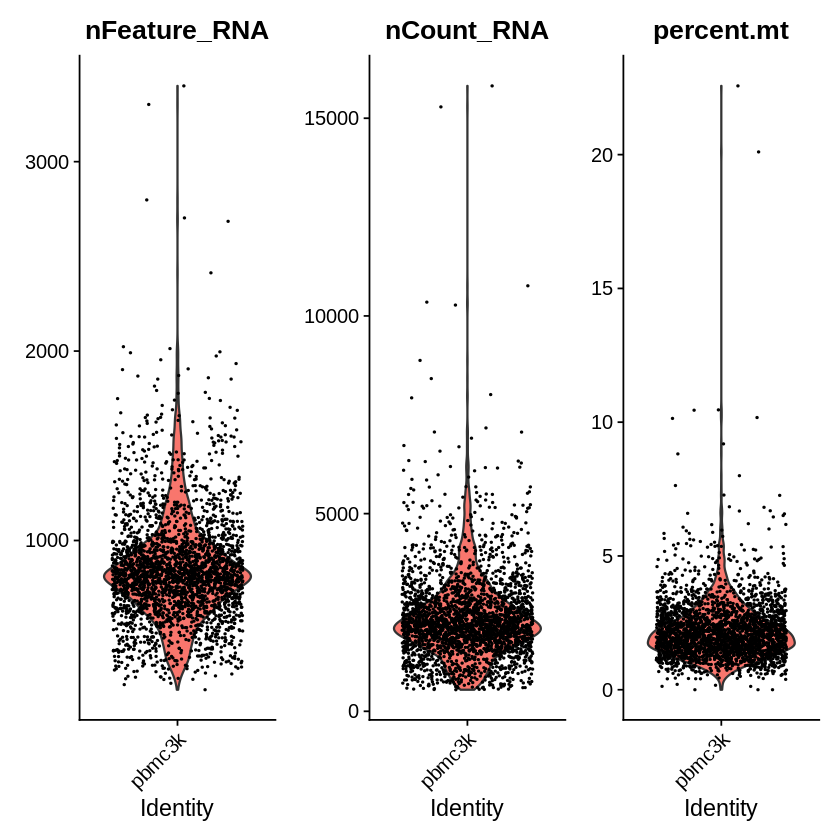

In [14]:
# Visualize QC metrics BEFORE filtering
VlnPlot(pbmc, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3)

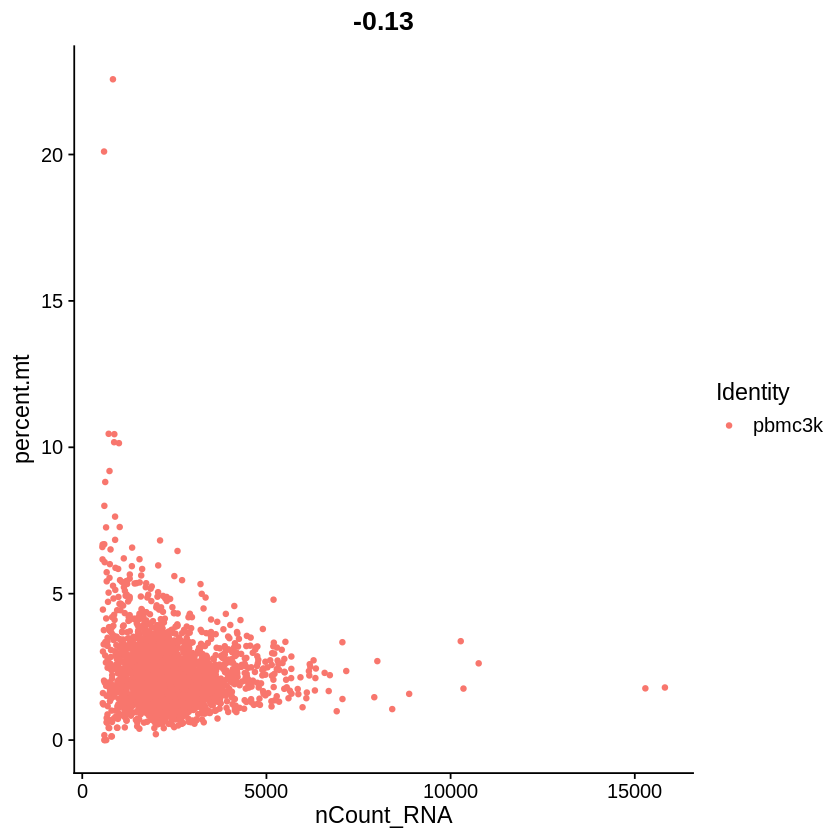

In [15]:
# Scatter plots to see relationships
FeatureScatter(pbmc, feature1 = "nCount_RNA", feature2 = "percent.mt")

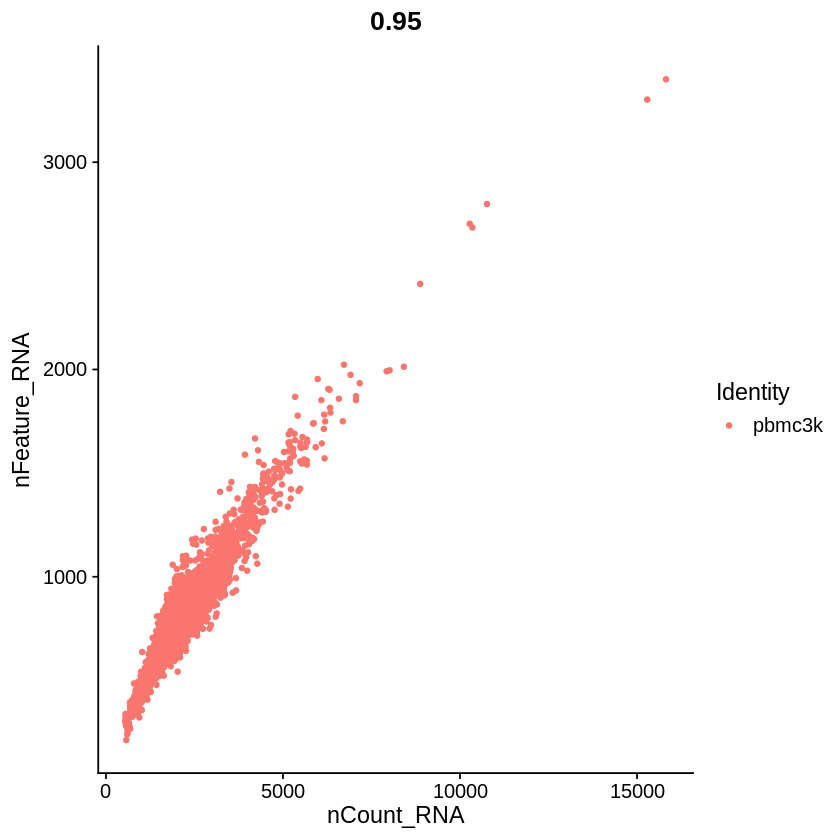

In [16]:
FeatureScatter(pbmc, feature1 = "nCount_RNA", feature2 = "nFeature_RNA")

In [17]:
# Filter: keep cells with 200-2500 genes and <5% mitochondrial content
pbmc <- subset(pbmc,
               subset = nFeature_RNA > 200 &
                        nFeature_RNA < 2500 &
                        percent.mt < 5)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


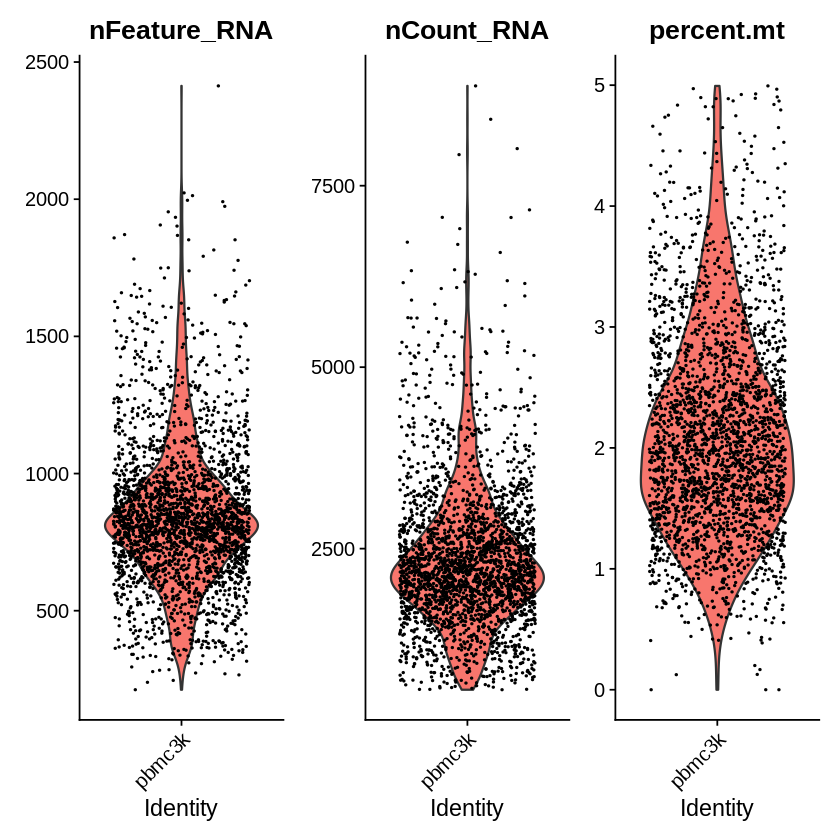

In [18]:
# Visualize QC metrics AFTER filtering
VlnPlot(pbmc, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3)

In [19]:
# Log-normalize: makes expression values comparable across cells
pbmc <- NormalizeData(pbmc,
                      normalization.method = "LogNormalize",
                      scale.factor = 10000)

Normalizing layer: counts



In [20]:
# Find the 2000 most variable genes (most informative)
pbmc <- FindVariableFeatures(pbmc,
                              selection.method = "vst",
                              nfeatures = 2000)

Finding variable features for layer counts



In [21]:
# See the top 10 most variable genes
top10 <- head(VariableFeatures(pbmc), 10)
top10

[1] "PPBP"   "LYZ"    "S100A9" "IGLL5"  "GNLY"   "FTL"    "PF4"    "FTH1"  
 [9] "GNG11"  "S100A8"

When using repel, set xnudge and ynudge to 0 for optimal results

Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”


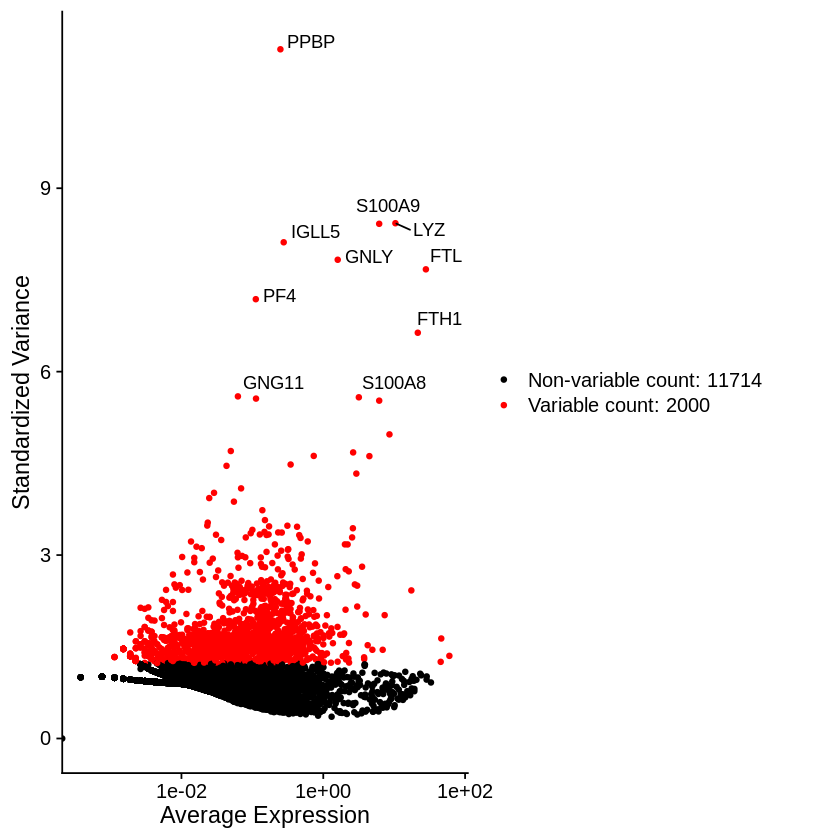

In [22]:
# Plot variable features
plot1 <- VariableFeaturePlot(pbmc)
LabelPoints(plot = plot1, points = top10, repel = TRUE)

Centering and scaling data matrix

PC_ 1 
Positive:  CST3, TYROBP, LST1, AIF1, FTL, FTH1, LYZ, FCN1, S100A9, TYMP 
	   FCER1G, CFD, LGALS1, S100A8, CTSS, LGALS2, SERPINA1, IFITM3, SPI1, CFP 
	   PSAP, IFI30, SAT1, COTL1, S100A11, NPC2, GRN, LGALS3, GSTP1, PYCARD 
Negative:  MALAT1, LTB, IL32, IL7R, CD2, B2M, ACAP1, CD27, STK17A, CTSW 
	   CD247, GIMAP5, AQP3, CCL5, SELL, TRAF3IP3, GZMA, MAL, CST7, ITM2A 
	   MYC, GIMAP7, HOPX, BEX2, LDLRAP1, GZMK, ETS1, ZAP70, TNFAIP8, RIC3 
PC_ 2 
Positive:  CD79A, MS4A1, TCL1A, HLA-DQA1, HLA-DQB1, HLA-DRA, LINC00926, CD79B, HLA-DRB1, CD74 
	   HLA-DMA, HLA-DPB1, HLA-DQA2, CD37, HLA-DRB5, HLA-DMB, HLA-DPA1, FCRLA, HVCN1, LTB 
	   BLNK, P2RX5, IGLL5, IRF8, SWAP70, ARHGAP24, FCGR2B, SMIM14, PPP1R14A, C16orf74 
Negative:  NKG7, PRF1, CST7, GZMB, GZMA, FGFBP2, CTSW, GNLY, B2M, SPON2 
	   CCL4, GZMH, FCGR3A, CCL5, CD247, XCL2, CLIC3, AKR1C3, SRGN, HOPX 
	   TTC38, APMAP, CTSC, S100A4, IGFBP7, ANXA1, ID2, IL32, XCL1, RHOC 
PC_ 3 
Positive:  HLA-DQA1, CD79A,

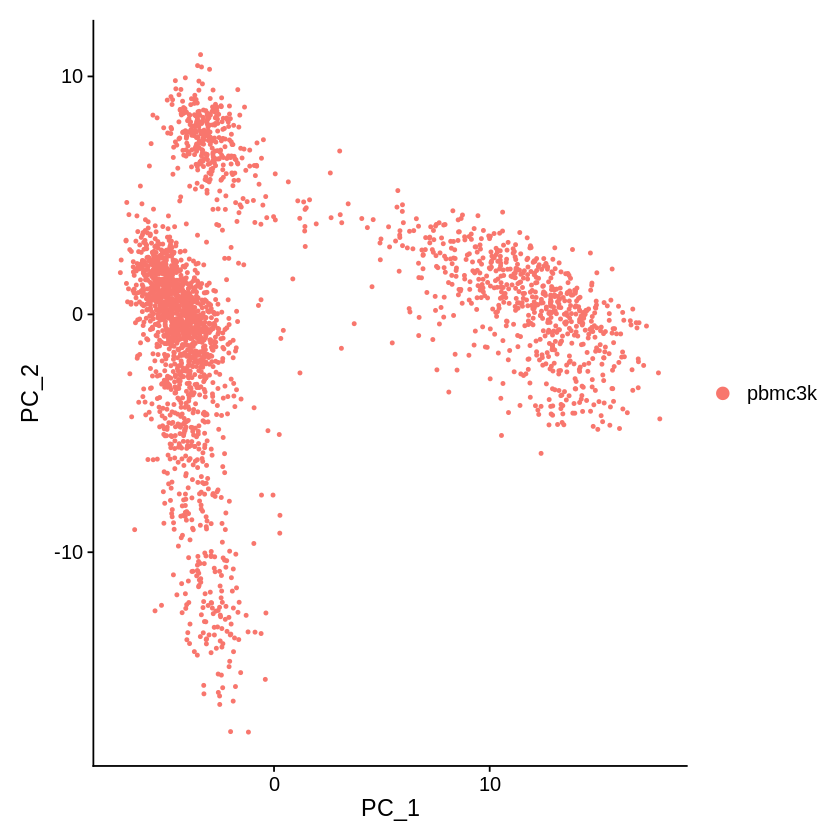

In [23]:
# Get all gene names
all.genes <- rownames(pbmc)
pbmc <- ScaleData(pbmc, features = all.genes)
pbmc <- RunPCA(pbmc, features = VariableFeatures(object = pbmc))
DimPlot(pbmc, reduction = "pca")

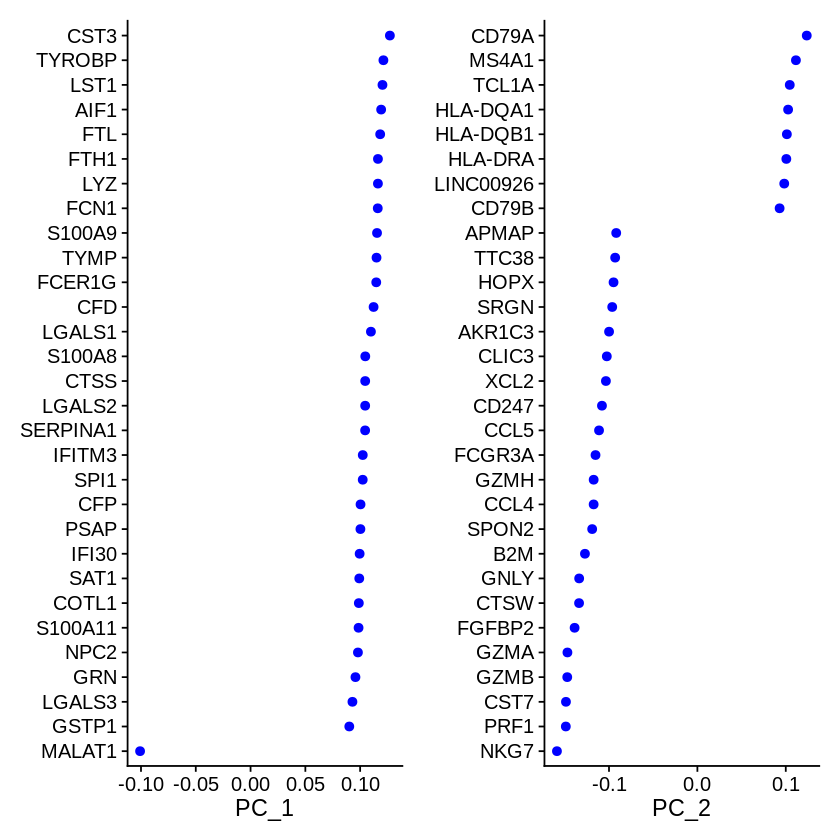

In [24]:
VizDimLoadings(pbmc, dims = 1:2, reduction = "pca")

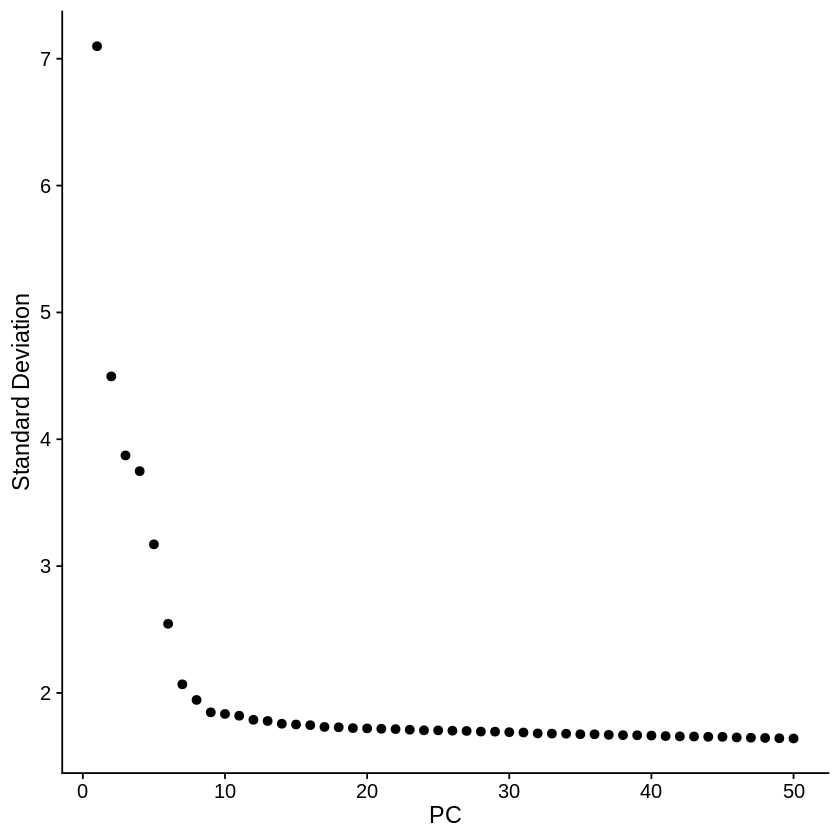

In [25]:
ElbowPlot(pbmc, ndims = 50)

In [26]:
pbmc <- FindNeighbors(pbmc, dims = 1:10)

Computing nearest neighbor graph

Computing SNN



In [27]:
# Find clusters (resolution = granularity)
pbmc <- FindClusters(pbmc, resolution = 0.5)

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 2638
Number of edges: 95965

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8723
Number of communities: 9
Elapsed time: 0 seconds


In [28]:
table(Idents(pbmc))


  0   1   2   3   4   5   6   7   8 
711 480 472 344 279 162 144  32  14 

In [29]:
pbmc <- RunUMAP(pbmc, dims = 1:10)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
10:35:02 UMAP embedding parameters a = 0.9922 b = 1.112

10:35:02 Read 2638 rows and found 10 numeric columns

10:35:02 Using Annoy for neighbor search, n_neighbors = 30

10:35:02 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

10:35:02 Writing NN index file to temp file /tmp/Rtmp9dHHSM/filef2964272c69

10:35:02 Searching Annoy index using 1 thread, search_k = 3000

10:35:03 Annoy recall = 100%

10:35:03 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 

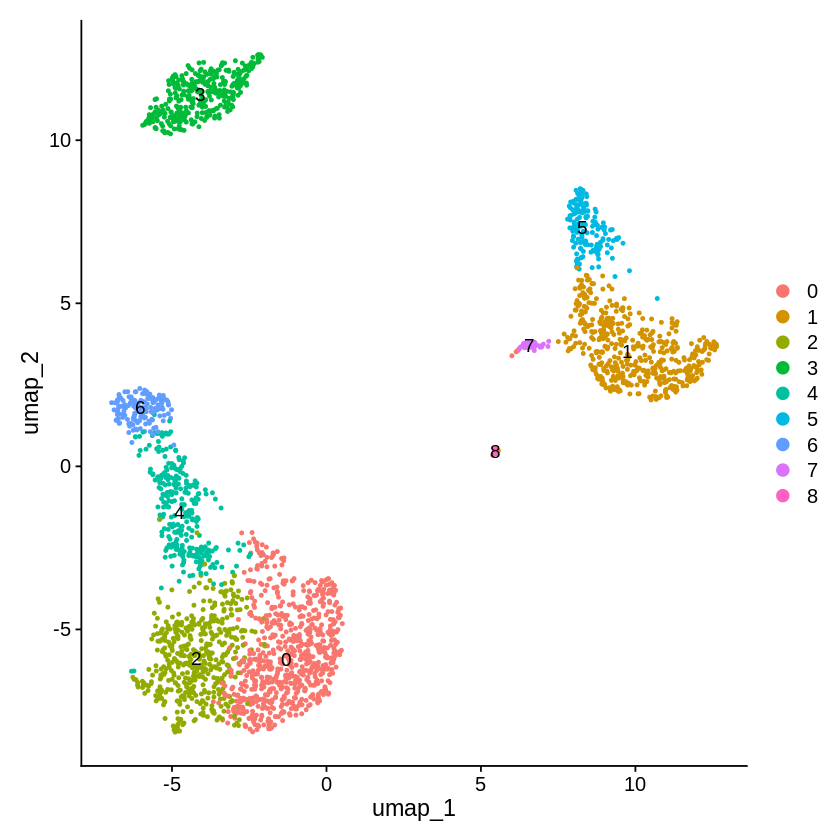

In [30]:
DimPlot(pbmc, reduction = "umap", label = TRUE)

In [31]:
# Find markers for all clusters
pbmc.markers <- FindAllMarkers(pbmc,
                                only.pos = TRUE,
                                min.pct = 0.25,
                                logfc.threshold = 0.25)

Calculating cluster 0

For a (much!) faster implementation of the Wilcoxon Rank Sum Test,
(default method for FindMarkers) please install the presto package
--------------------------------------------
install.packages('devtools')
devtools::install_github('immunogenomics/presto')
--------------------------------------------
After installation of presto, Seurat will automatically use the more 
efficient implementation (no further action necessary).
This message will be shown once per session

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8



In [32]:
# Look at the results
head(pbmc.markers)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
RPS12,1.806317e-144,0.7439459,1.000,0.991,2.477183e-140,0,RPS12
RPS6,7.135900e-142,0.6862148,1.000,0.995,9.786173e-138,0,RPS6
RPS27,5.257820e-140,0.7298479,0.999,0.992,7.210575e-136,0,RPS27
RPL32,4.229582e-136,0.6184804,0.999,0.995,5.800448e-132,0,RPL32
RPS14,1.799019e-130,0.6283021,1.000,0.994,2.467175e-126,0,RPS14
RPS25,5.507298e-123,0.7635765,0.997,0.975,7.552709e-119,0,RPS25


In [33]:
# Get top 10 markers per cluster
top10_markers <- pbmc.markers %>%
  group_by(cluster) %>%
  top_n(n = 10, wt = avg_log2FC)

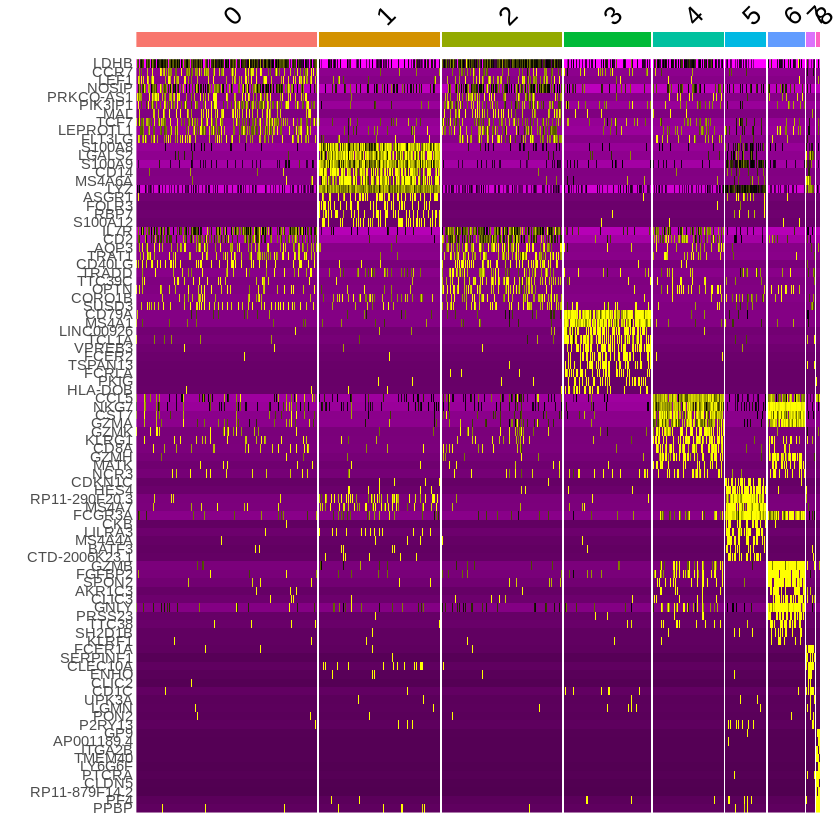

In [34]:
DoHeatmap(pbmc, features = top10_markers$gene) + NoLegend()

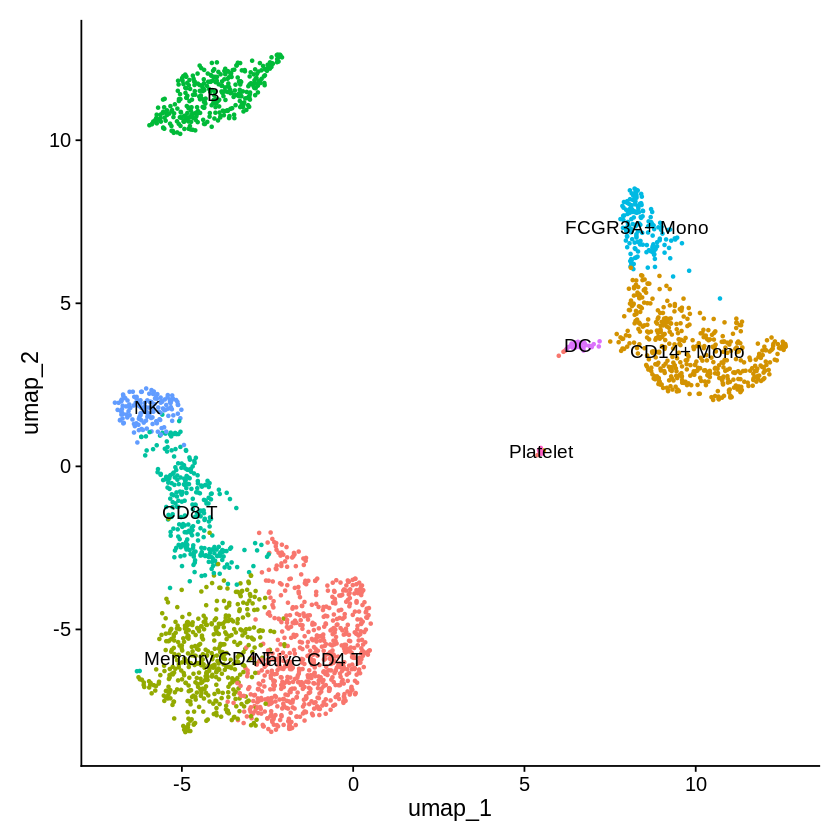

In [35]:
# Assign cell type names based on markers
new.cluster.ids <- c("Naive CD4 T", "CD14+ Mono", "Memory CD4 T",
                     "B", "CD8 T", "FCGR3A+ Mono",
                     "NK", "DC", "Platelet")
names(new.cluster.ids) <- levels(pbmc)
pbmc <- RenameIdents(pbmc, new.cluster.ids)

# Plot UMAP with cell type labels
DimPlot(pbmc, reduction = "umap", label = TRUE, pt.size = 0.5) + NoLegend()

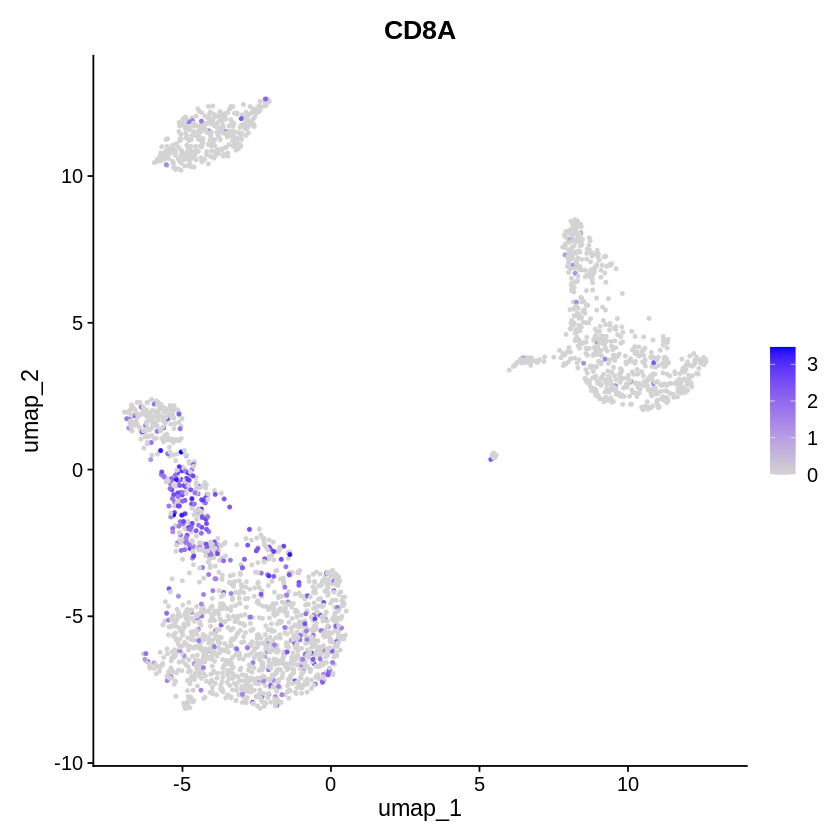

In [36]:
FeaturePlot(pbmc, features = c("CD8A"))  # CD8 T cell marker

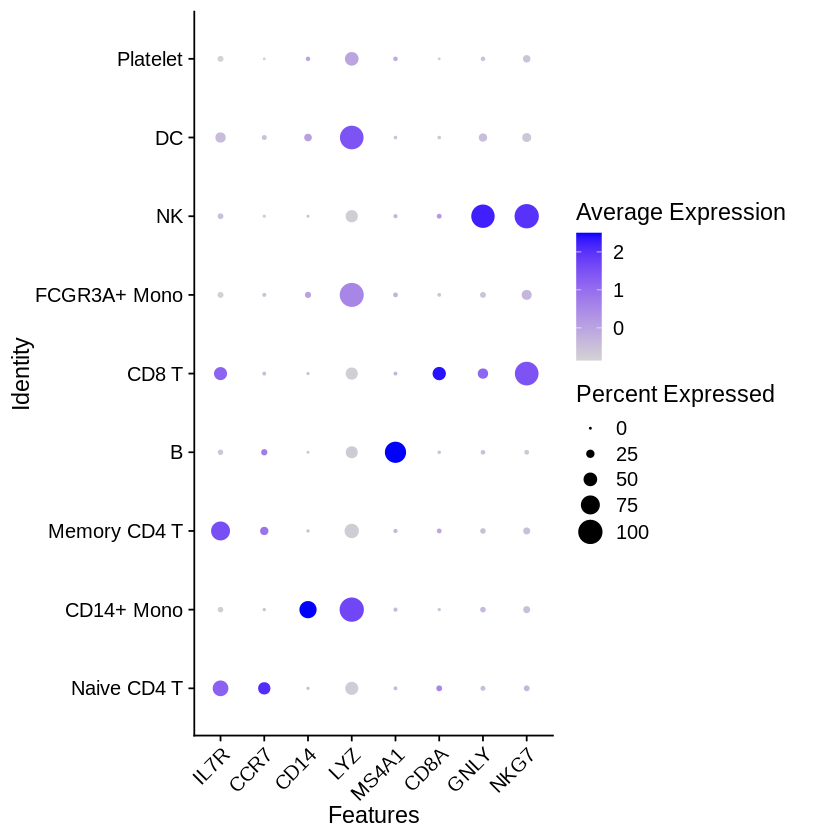

In [37]:
# Dot plot of canonical markers
DotPlot(pbmc, features = c("IL7R", "CCR7", "CD14", "LYZ",
                            "MS4A1", "CD8A", "GNLY", "NKG7")) +
  RotatedAxis()

In [38]:
# Compare two cell types
mono_de <- FindMarkers(pbmc,
                       ident.1 = "CD14+ Mono",
                       ident.2 = "FCGR3A+ Mono")

In [39]:
# Look at top results
head(mono_de)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
FCGR3A,1.193617e-101,-5.019527,0.131,0.975,1.636926e-97
LYZ,8.134552e-75,2.654926,1.000,0.988,1.115572e-70
RHOC,4.479768e-68,-3.319102,0.162,0.864,6.143554e-64
S100A8,7.471811e-65,4.017063,0.975,0.500,1.024684e-60
S100A9,1.318422e-64,3.395934,0.996,0.870,1.808084e-60
IFITM2,4.821669e-64,-2.227960,0.677,1.000,6.612437e-60


In [40]:
# Count cells per type
table(Idents(pbmc))


 Naive CD4 T   CD14+ Mono Memory CD4 T            B        CD8 T FCGR3A+ Mono 
         711          480          472          344          279          162 
          NK           DC     Platelet 
         144           32           14 

In [41]:

prop.table(table(Idents(pbmc))) * 100


 Naive CD4 T   CD14+ Mono Memory CD4 T            B        CD8 T FCGR3A+ Mono 
  26.9522365   18.1956027   17.8923427   13.0401820   10.5761941    6.1410159 
          NK           DC     Platelet 
   5.4586808    1.2130402    0.5307051 

In [42]:
saveRDS(pbmc, file = "pbmc_analyzed.rds")

In [43]:
# Install Monocle3 and dependencies
if (!requireNamespace("BiocManager", quietly = TRUE))
    install.packages("BiocManager")

BiocManager::install(c("monocle3", "slingshot", "SingleCellExperiment"))

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.22 (BiocManager 1.30.27), R 4.5.2 (2025-10-31)

Installing package(s) 'BiocVersion', 'monocle3', 'slingshot',
  'SingleCellExperiment'

Warning message:
“package ‘monocle3’ is not available for Bioconductor version '3.22'

A version of this package for your version of R might be available elsewhere,
see the ideas at
https://cran.r-project.org/doc/manuals/r-patched/R-admin.html#Installing-packages”
also installing the dependencies ‘XVector’, ‘MatrixGenerics’, ‘Biobase’, ‘IRanges’, ‘Seqinfo’, ‘S4Arrays’, ‘SparseArray’, ‘princurve’, ‘TrajectoryUtils’, ‘S4Vectors’, ‘SummarizedExperiment’, ‘BiocGenerics’, ‘GenomicRanges’, ‘DelayedArray’


Old packages: 'data.table', 'knitr', 'selectr', 'tidyr', 'x

In [44]:
# Extract only monocytes
mono_cells <- subset(pbmc, idents = c("CD14+ Mono", "FCGR3A+ Mono"))

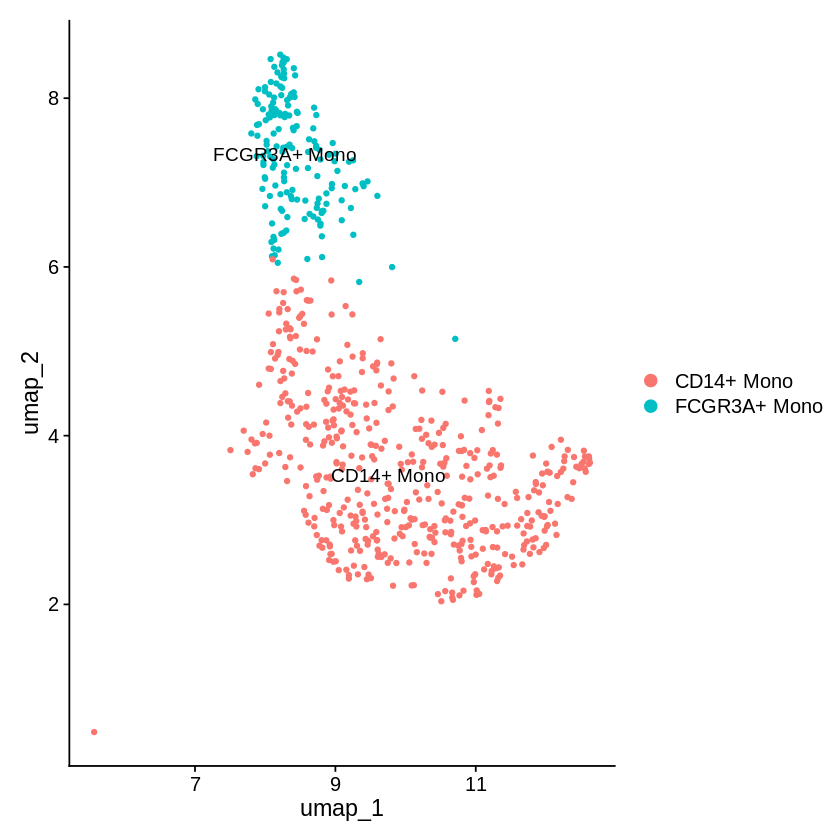

In [45]:
DimPlot(mono_cells, reduction = "umap", label = TRUE, pt.size = 1)

In [46]:
# Install SeuratWrappers (bridges Seurat and Monocle3)
if (!requireNamespace("remotes", quietly = TRUE))
    install.packages("remotes")

remotes::install_github('satijalab/seurat-wrappers')

xfun       (0.54   -> 0.55  ) [CRAN]
yaml       (2.3.11 -> 2.3.12) [CRAN]
knitr      (1.50   -> 1.51  ) [CRAN]
data.table (1.17.8 -> 1.18.0) [CRAN]
tidyr      (1.3.1  -> 1.3.2 ) [CRAN]
rsvd       (NA     -> 1.0.5 ) [CRAN]


Installing 6 packages: xfun, yaml, knitr, data.table, tidyr, rsvd

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



── R CMD build ─────────────────────────────────────────────────────────────────
* checking for file ‘/tmp/Rtmp9dHHSM/remotesf2930a322e0/satijalab-seurat-wrappers-a1eb0d8/DESCRIPTION’ ... OK
* preparing ‘SeuratWrappers’:
* checking DESCRIPTION meta-information ... OK
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
Omitted ‘LazyData’ from DESCRIPTION
* building ‘SeuratWrappers_0.4.0.tar.gz’



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Warning message in i.p(...):
“installation of package ‘/tmp/Rtmp9dHHSM/filef29350b92b0/SeuratWrappers_0.4.0.tar.gz’ had non-zero exit status”


In [48]:
mono_sce <- as.SingleCellExperiment(mono_cells)

In [49]:
# Install the missing package
BiocManager::install("DelayedMatrixStats")

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.22 (BiocManager 1.30.27), R 4.5.2 (2025-10-31)

Installing package(s) 'DelayedMatrixStats'

also installing the dependency ‘sparseMatrixStats’


Old packages: 'data.table', 'knitr', 'selectr', 'tidyr', 'xfun', 'yaml'



In [53]:
# Install Slingshot
BiocManager::install("slingshot")

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.22 (BiocManager 1.30.27), R 4.5.2 (2025-10-31)

Warning message:
“package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'slingshot'”
Old packages: 'data.table', 'knitr', 'selectr', 'tidyr', 'xfun', 'yaml'



In [55]:
library('slingshot')

Loading required package: princurve

Loading required package: TrajectoryUtils

Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘matrixStats’


The following object is masked from ‘package:dplyr’:

    count



Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, 

In [56]:
# Run Slingshot trajectory
mono_sling <- slingshot(mono_sce,
                        clusterLabels = "ident",
                        reducedDim = "UMAP",
                        start.clus = "CD14+ Mono")
# Extract pseudotime (progression along trajectory)
mono_pseudotime <- slingPseudotime(mono_sling)[,1]
mono_cells$pseudotime <- mono_pseudotime

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


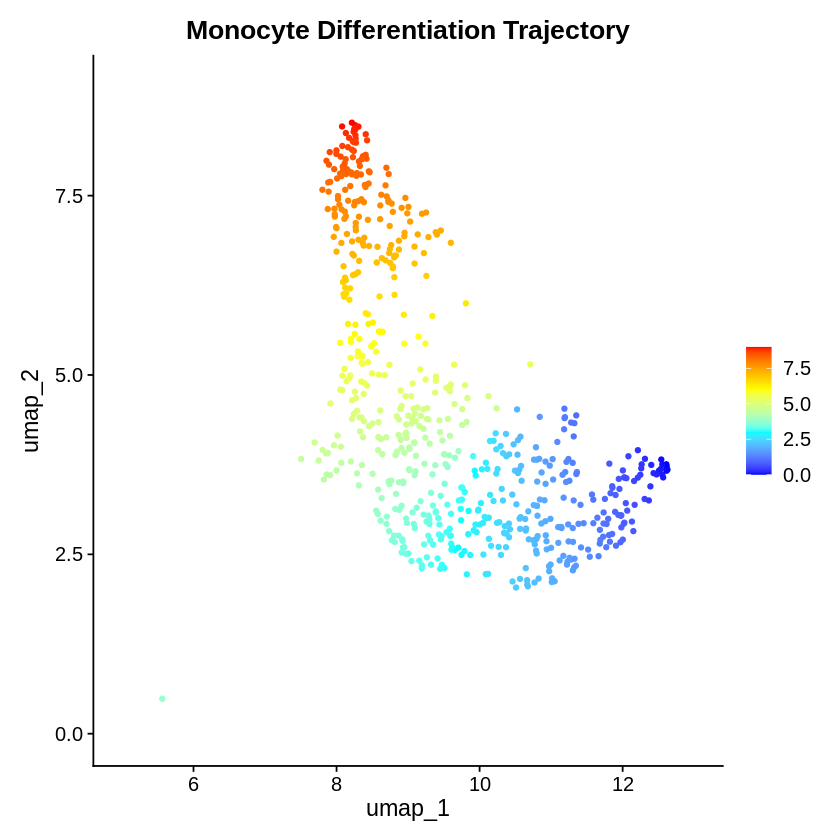

In [57]:
# Visualize pseudotime on UMAP
FeaturePlot(mono_cells,
            features = "pseudotime",
            reduction = "umap") +
  scale_color_gradientn(colors = c("blue", "cyan", "yellow", "red")) +
  ggtitle("Monocyte Differentiation Trajectory")

In [58]:
# Load libraries
library(slingshot)
library(SingleCellExperiment)
library(Seurat)
library(ggplot2)

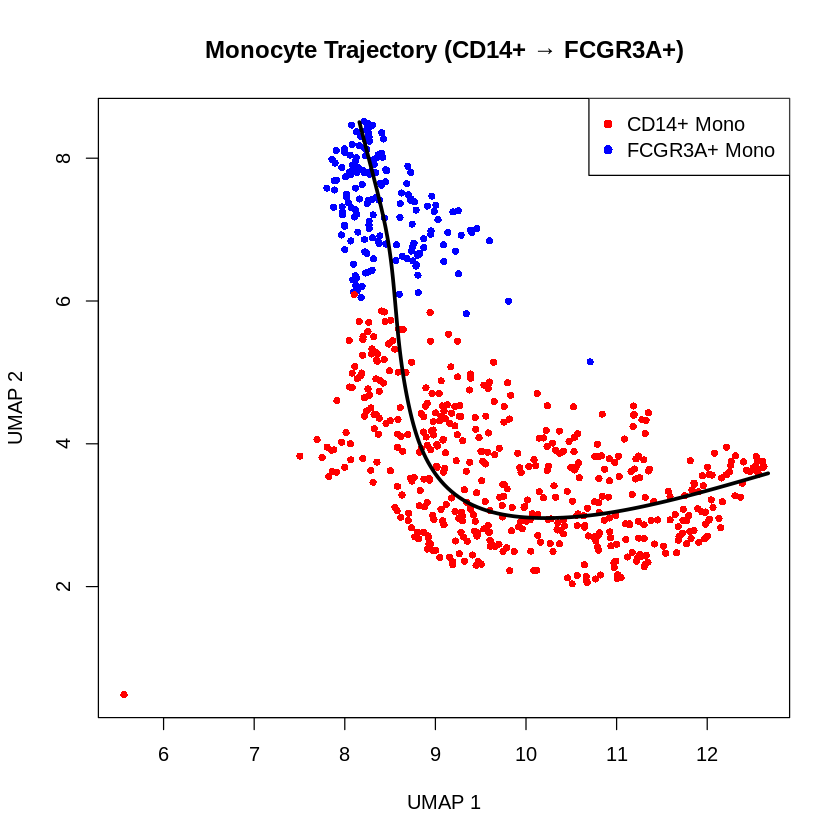

In [59]:
# Plot with trajectory curve overlaid
umap_coords <- Embeddings(mono_cells, "umap")
cell_colors <- c("CD14+ Mono" = "red", "FCGR3A+ Mono" = "blue")

plot(umap_coords,
     col = cell_colors[Idents(mono_cells)],
     pch = 16,
     cex = 0.8,
     main = "Monocyte Trajectory (CD14+ → FCGR3A+)",
     xlab = "UMAP 1",
     ylab = "UMAP 2")

# Add trajectory line
lines(SlingshotDataSet(mono_sling), lwd = 3, col = "black")

# Add legend
legend("topright",
       legend = names(cell_colors),
       col = cell_colors,
       pch = 16)

In [60]:
# Subset T cells
tcell_cells <- subset(pbmc, idents = c("Naive CD4 T", "Memory CD4 T", "CD8 T"))

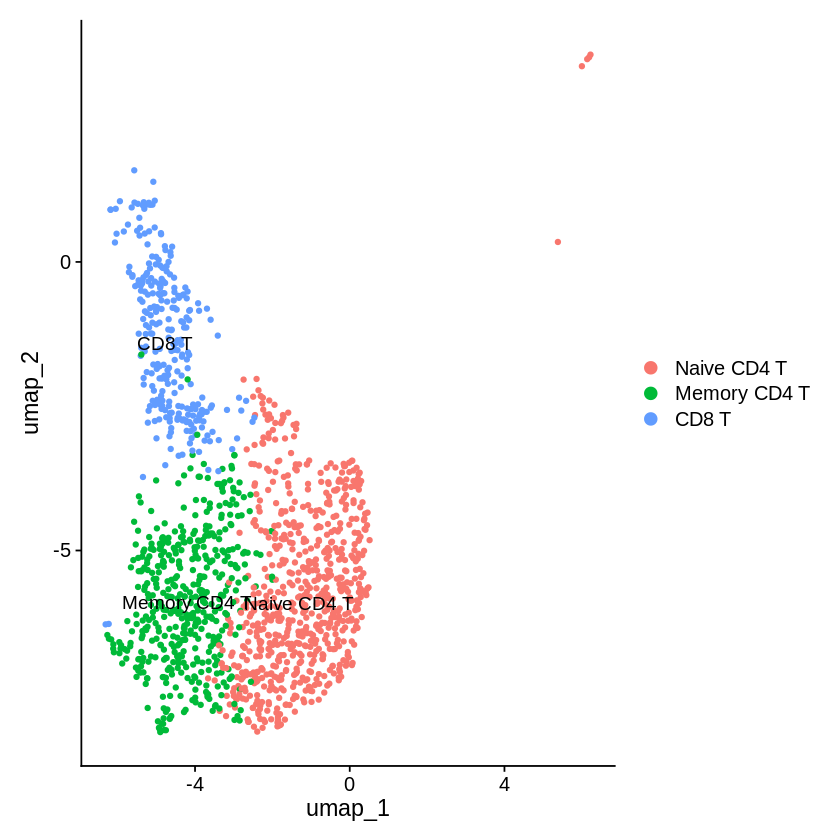

In [61]:
# Check
DimPlot(tcell_cells, reduction = "umap", label = TRUE)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


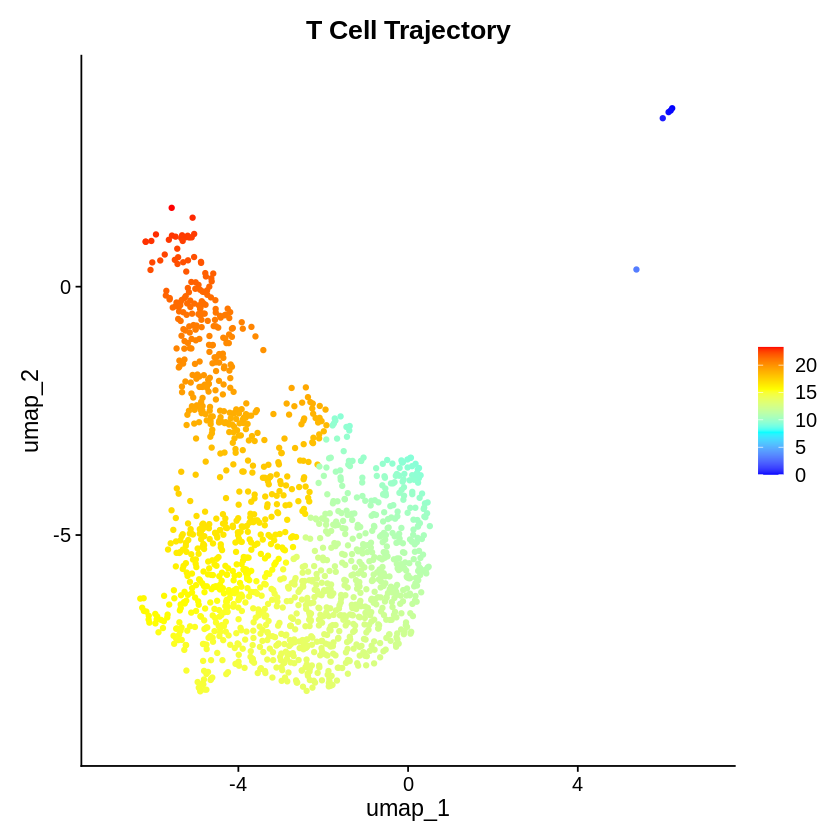

In [62]:
# Check
# Convert to SingleCellExperiment
tcell_sce <- as.SingleCellExperiment(tcell_cells)

# Run Slingshot
tcell_sling <- slingshot(tcell_sce,
                         clusterLabels = "ident",
                         reducedDim = "UMAP",
                         start.clus = "Naive CD4 T")

# Get pseudotime
tcell_pseudotime <- slingPseudotime(tcell_sling)[,1]
tcell_cells$pseudotime <- tcell_pseudotime

# Visualize
FeaturePlot(tcell_cells,
            features = "pseudotime",
            reduction = "umap") +
  scale_color_gradientn(colors = c("blue", "cyan", "yellow", "red")) +
  ggtitle("T Cell Trajectory")

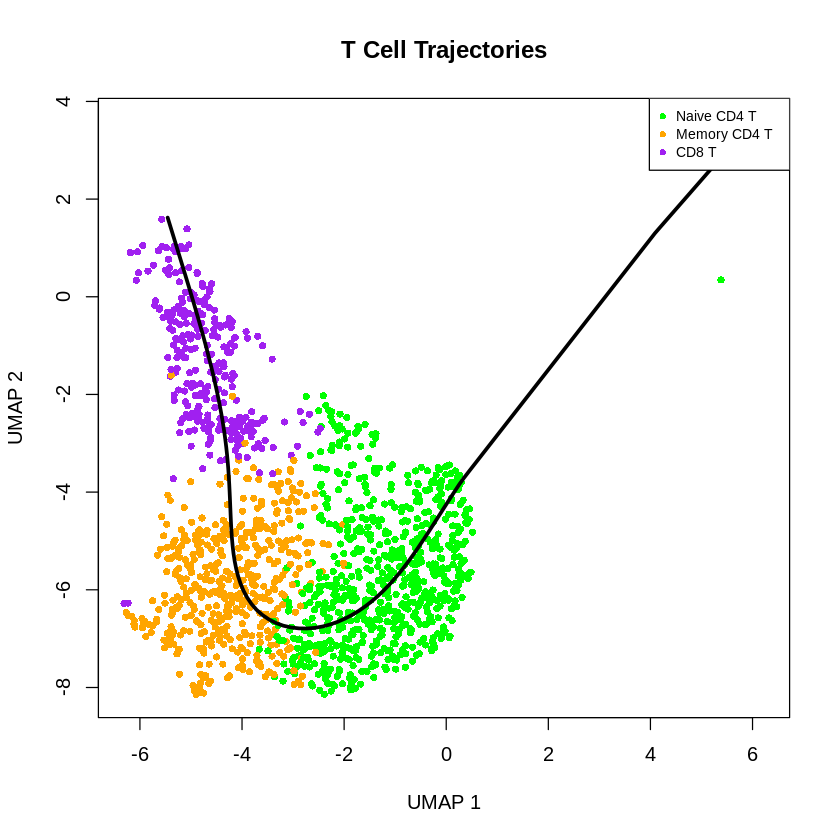

In [63]:
# Plot with trajectory curves
umap_tcell <- Embeddings(tcell_cells, "umap")
tcell_colors <- c("Naive CD4 T" = "green",
                  "Memory CD4 T" = "orange",
                  "CD8 T" = "purple")

plot(umap_tcell,
     col = tcell_colors[Idents(tcell_cells)],
     pch = 16,
     cex = 0.8,
     main = "T Cell Trajectories",
     xlab = "UMAP 1",
     ylab = "UMAP 2")

lines(SlingshotDataSet(tcell_sling), lwd = 3, col = "black")

legend("topright",
       legend = names(tcell_colors),
       col = tcell_colors,
       pch = 16,
       cex = 0.7)

In [64]:
# Get expression matrix (NEW syntax)
expr_mono <- as.matrix(GetAssayData(mono_cells, layer = "data"))
# Correlate with pseudotime
gene_cors <- apply(expr_mono, 1, function(gene_expr) {
  cor(gene_expr, mono_cells$pseudotime, method = "spearman", use = "complete.obs")
})

Warning message in cor(gene_expr, mono_cells$pseudotime, method = "spearman", use = "complete.obs"):
“the standard deviation is zero”
Warning message in cor(gene_expr, mono_cells$pseudotime, method = "spearman", use = "complete.obs"):
“the standard deviation is zero”
Warning message in cor(gene_expr, mono_cells$pseudotime, method = "spearman", use = "complete.obs"):
“the standard deviation is zero”
Warning message in cor(gene_expr, mono_cells$pseudotime, method = "spearman", use = "complete.obs"):
“the standard deviation is zero”
Warning message in cor(gene_expr, mono_cells$pseudotime, method = "spearman", use = "complete.obs"):
“the standard deviation is zero”
Warning message in cor(gene_expr, mono_cells$pseudotime, method = "spearman", use = "complete.obs"):
“the standard deviation is zero”
Warning message in cor(gene_expr, mono_cells$pseudotime, method = "spearman", use = "complete.obs"):
“the standard deviation is zero”
Warning message in cor(gene_expr, mono_cells$pseudotime, metho

In [65]:
# Sort genes
gene_cors <- sort(gene_cors, decreasing = TRUE)
# Top genes increasing along trajectory
cat("Top genes increasing:\n")
head(gene_cors, 10)

# Top genes decreasing along trajectory
cat("\nTop genes decreasing:\n")
tail(gene_cors, 10)

# Get gene names
top_increasing <- names(head(gene_cors, 3))
top_decreasing <- names(tail(gene_cors, 3))
all_top <- c(top_increasing, top_decreasing)

Top genes increasing:


FCGR3A      RHOC    IFITM2      ABI3     RPS19     MS4A7       B2M     COTL1 
0.7450052 0.6623243 0.6339321 0.5758372 0.5348656 0.5215967 0.5188134 0.5128680 
   IFITM3  HLA-DPA1 
0.5032566 0.5016629


Top genes decreasing:


GSTP1      RPL32     MS4A6A      RPLP1      RPL13     LGALS2       GPX1 
-0.3483985 -0.3591737 -0.3680439 -0.3802002 -0.4088031 -0.4619834 -0.4703877 
       LYZ     S100A9     S100A8 
-0.5210096 -0.7173377 -0.7874557

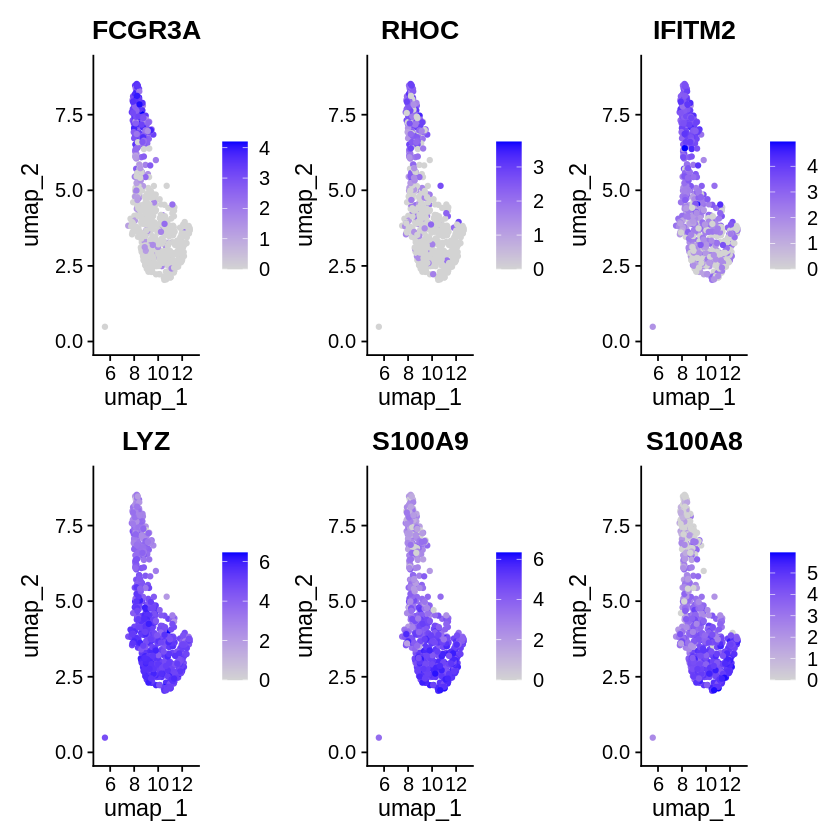

In [66]:
FeaturePlot(mono_cells, features = all_top, reduction = "umap", ncol = 3)

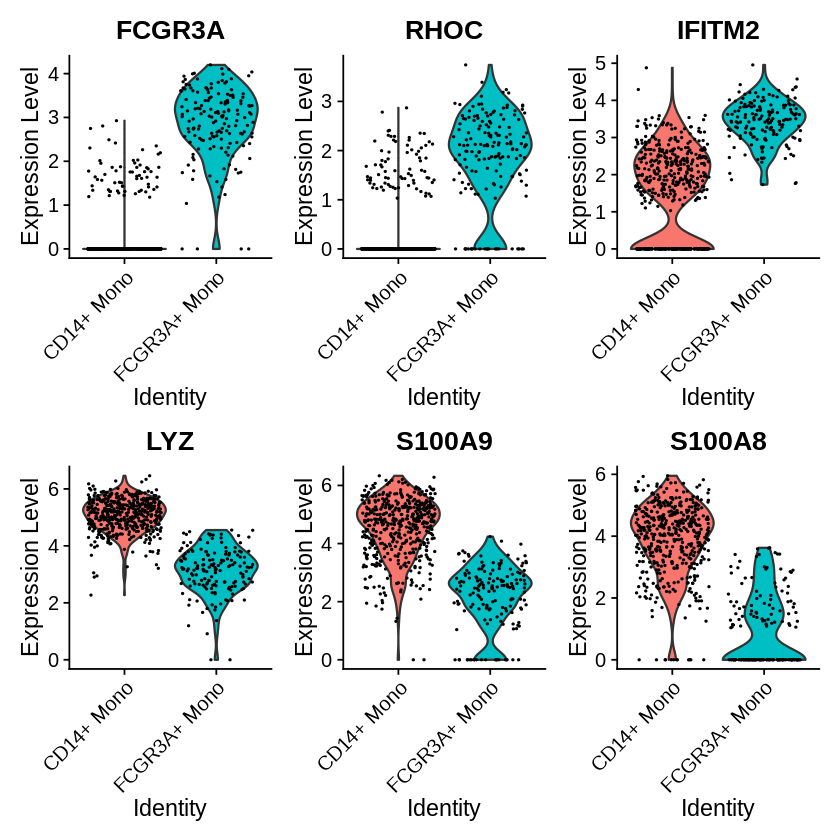

In [67]:
# Violin plots by cell type
VlnPlot(mono_cells, features = all_top, ncol = 3, pt.size = 0.1)

In [68]:
# Function to plot gene along pseudotime
library(ggplot2)

plot_trajectory_gene <- function(gene_name) {
  gene_data <- expr_mono[gene_name, ]

  plot_df <- data.frame(
    pseudotime = mono_cells$pseudotime,
    expression = gene_data,
    cell_type = Idents(mono_cells)
  )

  ggplot(plot_df, aes(x = pseudotime, y = expression, color = cell_type)) +
    geom_point(alpha = 0.6, size = 1.5) +
    geom_smooth(method = "loess", se = TRUE, color = "black", linewidth = 1.5) +
    scale_color_manual(values = c("CD14+ Mono" = "red", "FCGR3A+ Mono" = "blue")) +
    labs(title = paste(gene_name, "along trajectory"),
         x = "Pseudotime (Distance from CD14+ Mono)",
         y = "Expression Level") +
    theme_minimal() +
    theme(plot.title = element_text(hjust = 0.5, face = "bold"))
}

`geom_smooth()` using formula = 'y ~ x'


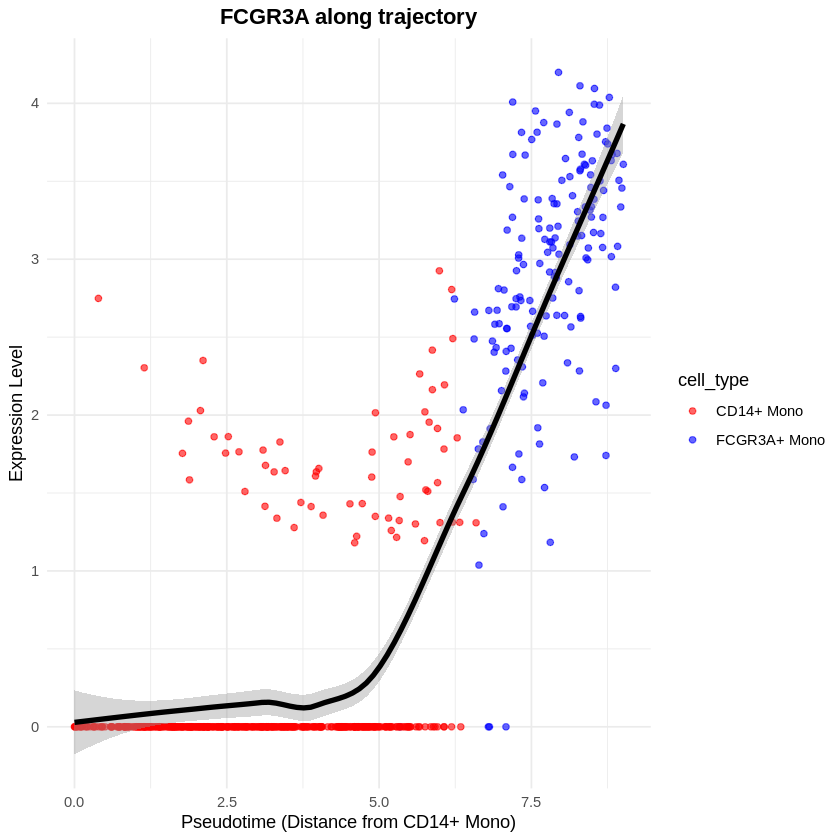

In [69]:
# Plot top increasing gene
plot_trajectory_gene(top_increasing[1])

`geom_smooth()` using formula = 'y ~ x'


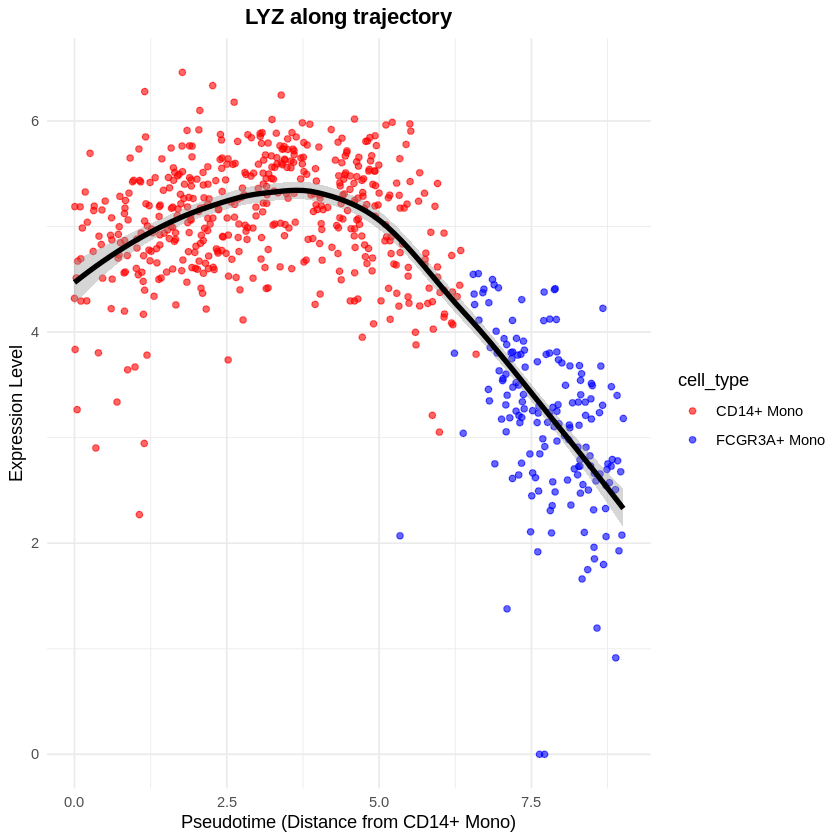

In [70]:
# Plot top decreasing gene
plot_trajectory_gene(top_decreasing[1])

`geom_smooth()` using formula = 'y ~ x'


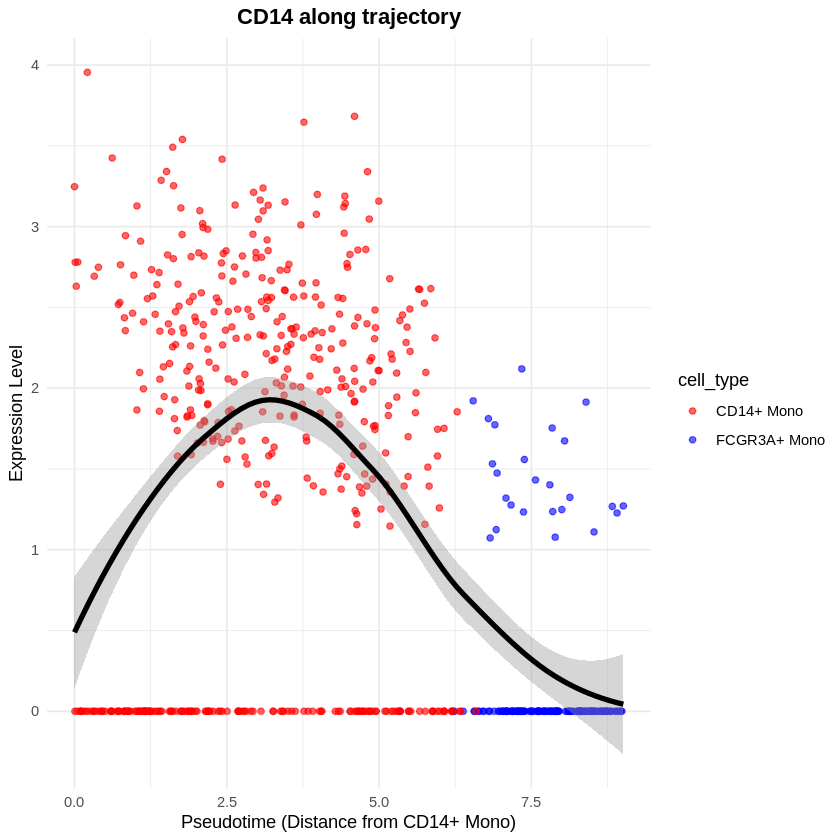

In [71]:
# Plot another known marker
plot_trajectory_gene("CD14")

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


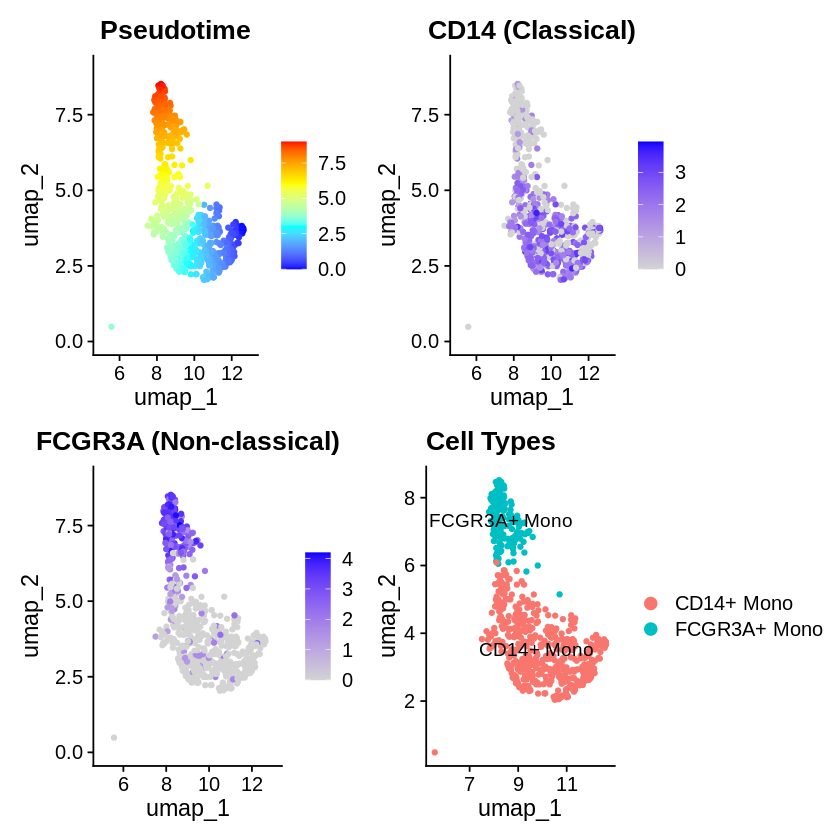

In [72]:
# Create 4-panel figure
library(patchwork)

p1 <- FeaturePlot(mono_cells, features = "pseudotime", reduction = "umap") +
  scale_color_gradientn(colors = c("blue", "cyan", "yellow", "red")) +
  ggtitle("Pseudotime")

p2 <- FeaturePlot(mono_cells, features = "CD14", reduction = "umap") +
  ggtitle("CD14 (Classical)")

p3 <- FeaturePlot(mono_cells, features = "FCGR3A", reduction = "umap") +
  ggtitle("FCGR3A (Non-classical)")

p4 <- DimPlot(mono_cells, reduction = "umap", label = TRUE, pt.size = 1) +
  ggtitle("Cell Types")

# Combine
(p1 | p2) / (p3 | p4)

In [73]:
# Get UMAP coordinates
umap_coords <- Embeddings(mono_cells, "umap")
head(umap_coords)

,umap_1,umap_2
AAACCGTGCTTCCG-1,9.145644,5.535673
AAACGCTGTTTCTG-1,9.458003,7.013417
AAAGAGACGCGAGA-1,9.091708,3.603109
AAAGCAGATATCGG-1,8.362432,5.260313
AAAGTTTGTAGCGT-1,10.992380,2.357885
AAATCAACCCTATT-1,7.858966,7.985243


In [74]:
# Function to plot gene vs pseudotime
plot_gene_pseudotime <- function(gene_name) {
  gene_expr <- expr_mono[gene_name, ]

  df <- data.frame(
    pseudotime = mono_cells$pseudotime,
    expression = gene_expr,
    cell_type = Idents(mono_cells)
  )

  ggplot(df, aes(x = pseudotime, y = expression, color = cell_type)) +
    geom_point(alpha = 0.5, size = 2) +
    geom_smooth(method = "loess", se = TRUE, color = "black") +
    labs(title = paste(gene_name, "expression along trajectory"),
         x = "Pseudotime",
         y = "Expression") +
    theme_minimal()
}

In [75]:
# Plot top increasing gene
# Get monocytes
mono_cells <- subset(pbmc, idents = c("CD14+ Mono", "FCGR3A+ Mono"))

In [76]:
# Get UMAP coordinates
umap_coords <- Embeddings(mono_cells, "umap")

In [77]:
# Find CD14+ Mono centroid (starting point)
cd14_cells <- WhichCells(mono_cells, idents = "CD14+ Mono")
cd14_centroid <- colMeans(umap_coords[cd14_cells, ])

print("CD14+ centroid:")
print(cd14_centroid)

[1] "CD14+ centroid:"
  umap_1   umap_2 
9.963179 3.581316 


In [78]:
# Calculate distance from CD14+ centroid for each cell
distances <- apply(umap_coords, 1, function(cell) {
  sqrt(sum((cell - cd14_centroid)^2))
})

In [79]:
# Add to Seurat object as pseudotime
mono_cells$pseudotime <- distances

In [80]:
# Check it worked
head(mono_cells$pseudotime)

AAACCGTGCTTCCG-1 AAACGCTGTTTCTG-1 AAAGAGACGCGAGA-1 AAAGCAGATATCGG-1 
       2.1184608        3.4690800        0.8717425        2.3197888 
AAAGTTTGTAGCGT-1 AAATCAACCCTATT-1 
       1.5987623        4.8808076

In [81]:
# Quick check - see range
summary(mono_cells$pseudotime)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.02375 1.09227 1.66219 2.09142 2.78961 5.37938 

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


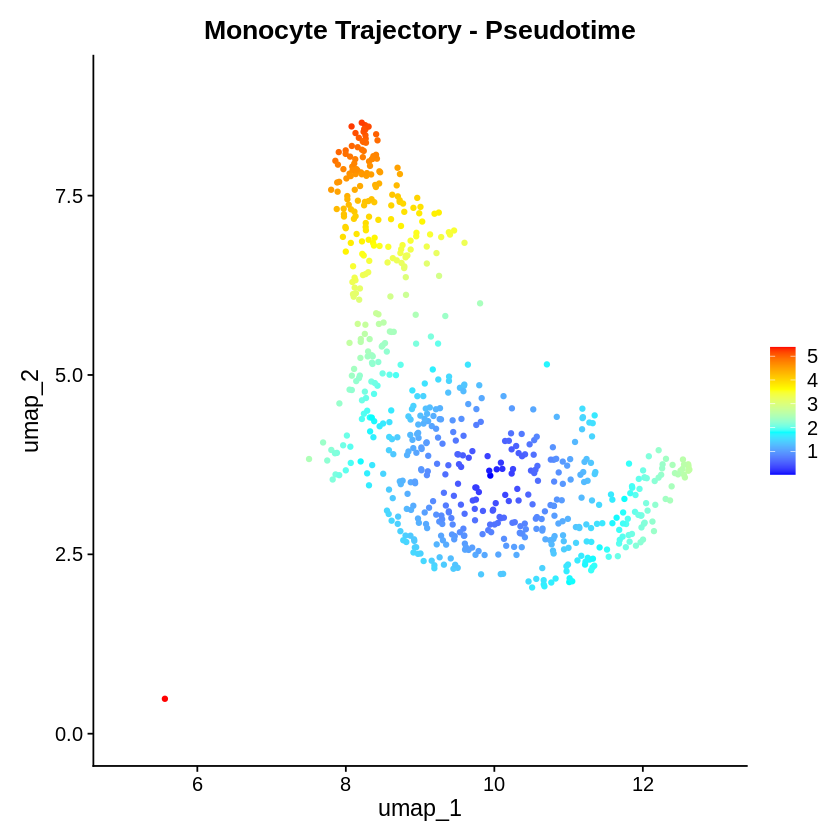

In [82]:
# Plot pseudotime on UMAP
FeaturePlot(mono_cells, features = "pseudotime", reduction = "umap") +
  scale_color_gradientn(colors = c("blue", "cyan", "yellow", "red")) +
  ggtitle("Monocyte Trajectory - Pseudotime")

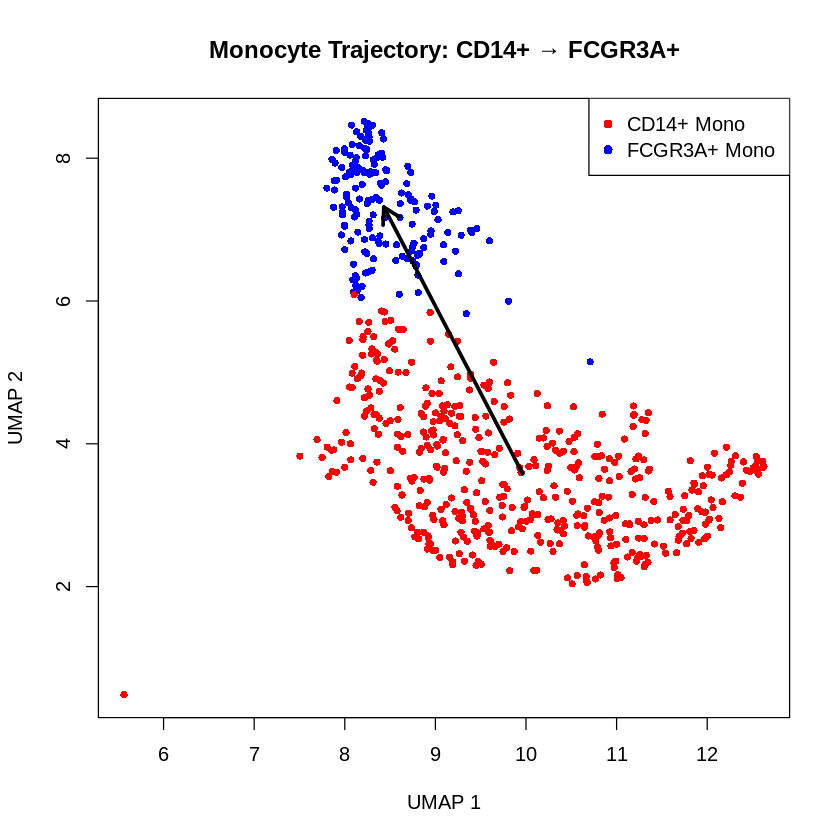

In [83]:
# Traditional plot with arrow
plot(umap_coords,
     col = ifelse(Idents(mono_cells) == "CD14+ Mono", "red", "blue"),
     pch = 16,
     cex = 0.8,
     main = "Monocyte Trajectory: CD14+ → FCGR3A+",
     xlab = "UMAP 1",
     ylab = "UMAP 2")

# Add arrow showing trajectory direction
fcgr3a_cells <- WhichCells(mono_cells, idents = "FCGR3A+ Mono")
fcgr3a_centroid <- colMeans(umap_coords[fcgr3a_cells, ])

arrows(cd14_centroid[1], cd14_centroid[2],
       fcgr3a_centroid[1], fcgr3a_centroid[2],
       lwd = 3, length = 0.15, col = "black")

legend("topright",
       legend = c("CD14+ Mono", "FCGR3A+ Mono"),
       col = c("red", "blue"),
       pch = 16)

In [84]:
# Get expression data (using NEW syntax)
expr_mono <- as.matrix(GetAssayData(mono_cells, layer = "data"))
# Correlate each gene with pseudotime
gene_cors <- apply(expr_mono, 1, function(gene_expr) {
  cor(gene_expr, mono_cells$pseudotime, method = "spearman", use = "complete.obs")
})

Warning message in cor(gene_expr, mono_cells$pseudotime, method = "spearman", use = "complete.obs"):
“the standard deviation is zero”
Warning message in cor(gene_expr, mono_cells$pseudotime, method = "spearman", use = "complete.obs"):
“the standard deviation is zero”
Warning message in cor(gene_expr, mono_cells$pseudotime, method = "spearman", use = "complete.obs"):
“the standard deviation is zero”
Warning message in cor(gene_expr, mono_cells$pseudotime, method = "spearman", use = "complete.obs"):
“the standard deviation is zero”
Warning message in cor(gene_expr, mono_cells$pseudotime, method = "spearman", use = "complete.obs"):
“the standard deviation is zero”
Warning message in cor(gene_expr, mono_cells$pseudotime, method = "spearman", use = "complete.obs"):
“the standard deviation is zero”
Warning message in cor(gene_expr, mono_cells$pseudotime, method = "spearman", use = "complete.obs"):
“the standard deviation is zero”
Warning message in cor(gene_expr, mono_cells$pseudotime, metho

In [85]:
# Get top genes
top_increasing <- names(head(gene_cors, 3))
top_decreasing <- names(tail(gene_cors, 3))
all_top_genes <- c(top_increasing, top_decreasing)

Warning message:
“All cells have the same value (0) of “RP11-206L10.2””


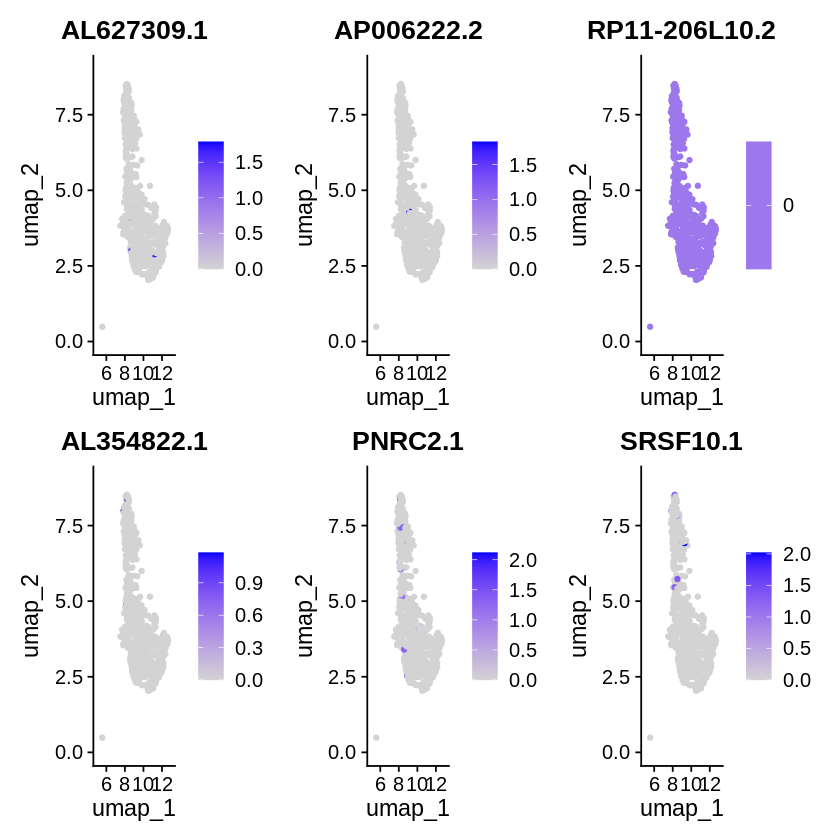

In [86]:
# Feature plots
FeaturePlot(mono_cells, features = all_top_genes, reduction = "umap", ncol = 3)

Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of RP11-206L10.2.”


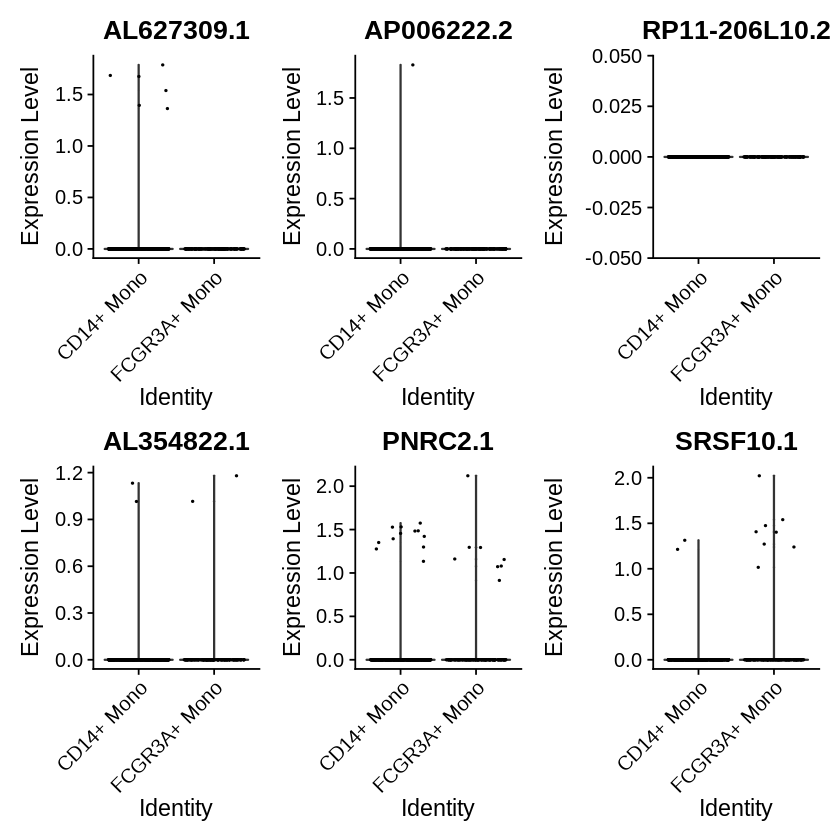

In [87]:
# Violin plots
VlnPlot(mono_cells, features = all_top_genes, ncol = 3, pt.size = 0.1)

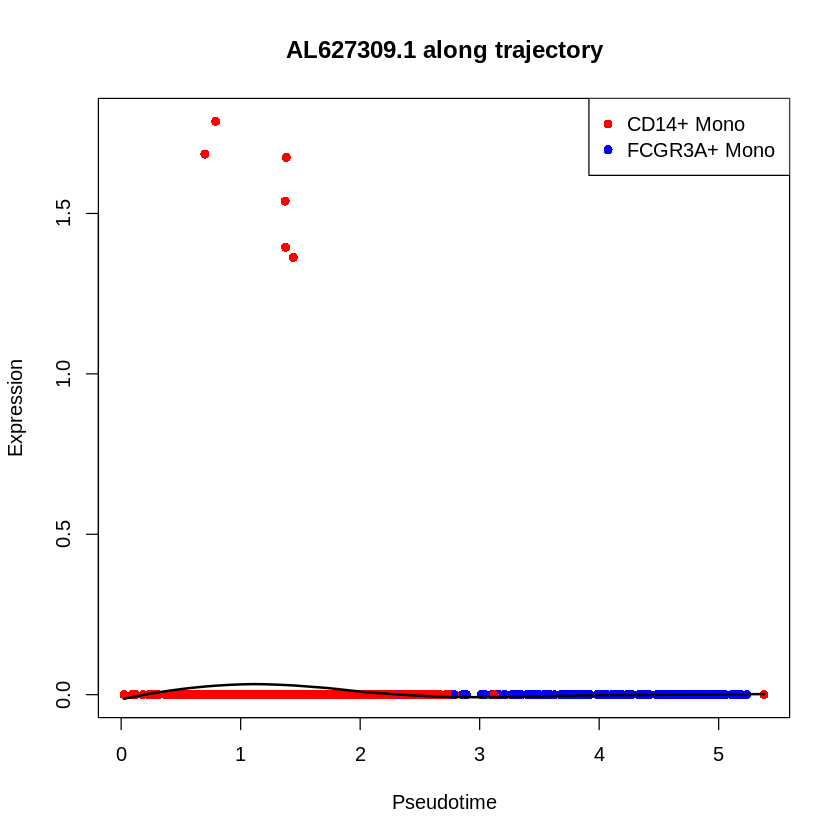

In [88]:
# Simple scatter for one gene
gene_to_plot <- top_increasing[1]

plot(mono_cells$pseudotime,
     expr_mono[gene_to_plot, ],
     col = ifelse(Idents(mono_cells) == "CD14+ Mono", "red", "blue"),
     pch = 16,
     xlab = "Pseudotime",
     ylab = "Expression",
     main = paste(gene_to_plot, "along trajectory"))

# Add smooth line
lo <- loess(expr_mono[gene_to_plot, ] ~ mono_cells$pseudotime)
pred <- predict(lo, se = TRUE)
lines(sort(mono_cells$pseudotime), pred$fit[order(mono_cells$pseudotime)],
      lwd = 2, col = "black")

legend("topright",
       legend = c("CD14+ Mono", "FCGR3A+ Mono"),
       col = c("red", "blue"),
       pch = 16)

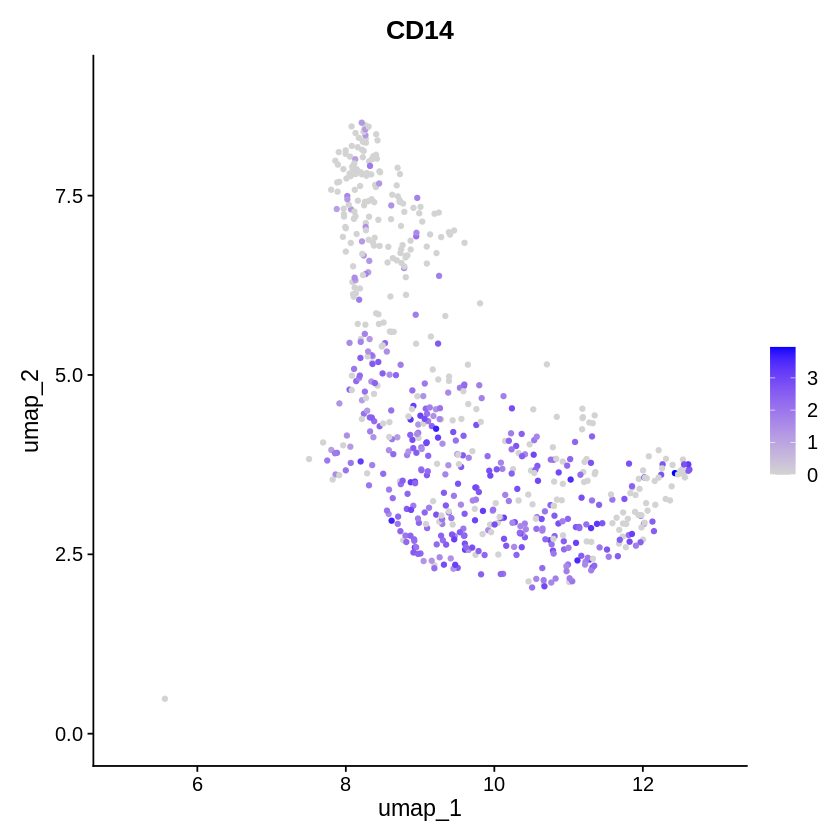

In [89]:
# CD14 should decrease (classical monocyte marker)
FeaturePlot(mono_cells, features = "CD14", reduction = "umap")

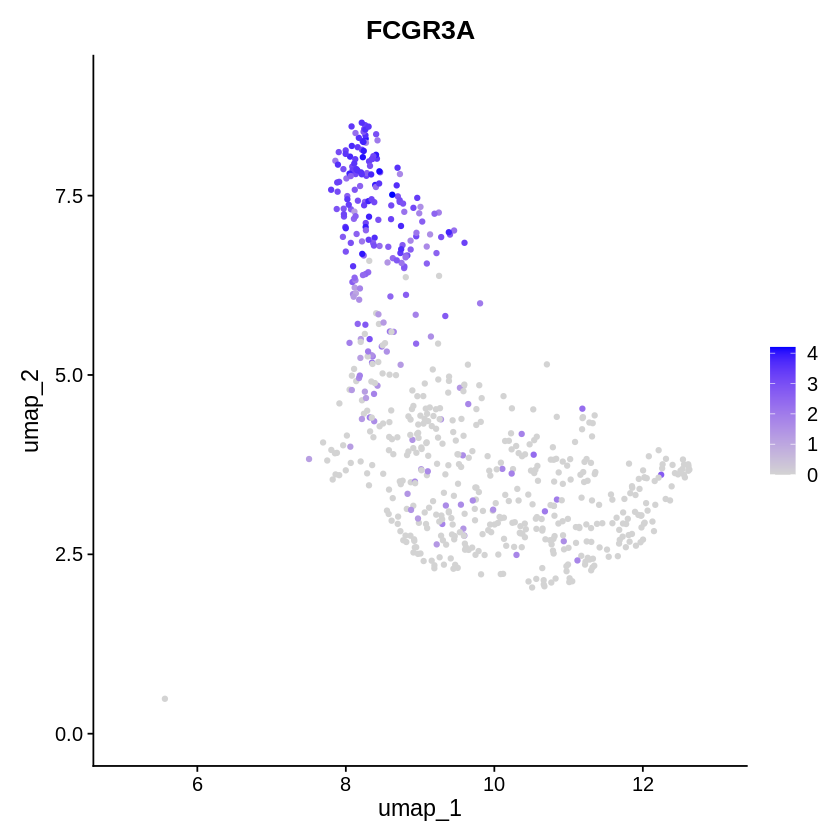

In [90]:
# FCGR3A should increase (non-classical marker)
FeaturePlot(mono_cells, features = "FCGR3A", reduction = "umap")

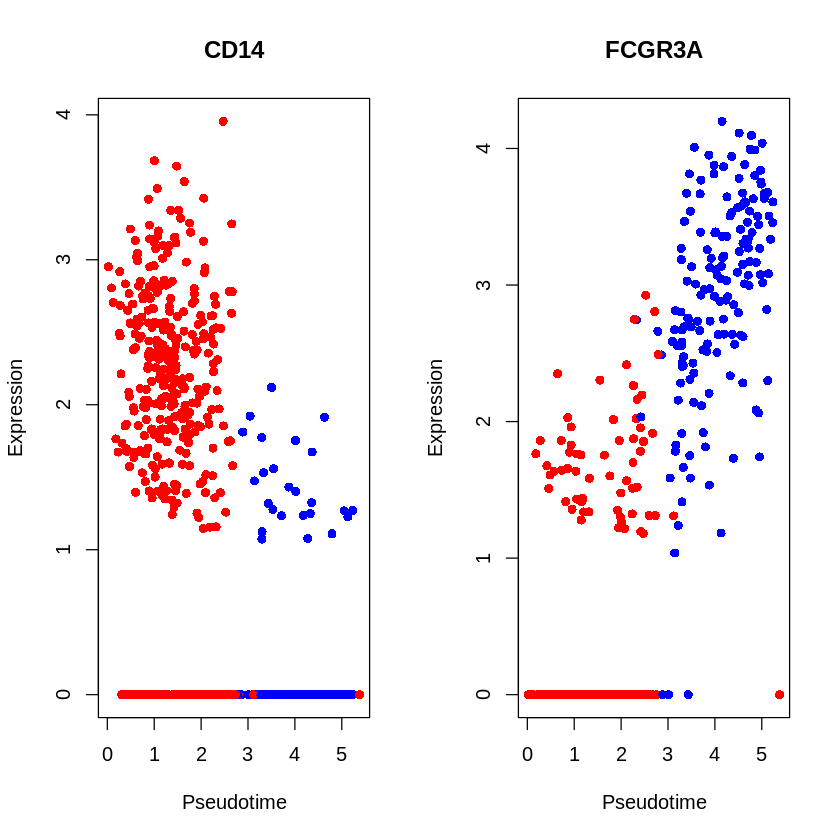

In [91]:
# Plot both vs pseudotime
par(mfrow = c(1, 2))

# CD14
plot(mono_cells$pseudotime, expr_mono["CD14", ],
     col = ifelse(Idents(mono_cells) == "CD14+ Mono", "red", "blue"),
     pch = 16, main = "CD14", xlab = "Pseudotime", ylab = "Expression")

# FCGR3A
plot(mono_cells$pseudotime, expr_mono["FCGR3A", ],
     col = ifelse(Idents(mono_cells) == "CD14+ Mono", "red", "blue"),
     pch = 16, main = "FCGR3A", xlab = "Pseudotime", ylab = "Expression")

par(mfrow = c(1, 1))